In [146]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import io

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix

import plotly.express as px
import plotly.graph_objects as go

from fastapi import FastAPI, File, UploadFile, HTTPException
from pydantic import BaseModel


In [147]:
import importlib

modules = [
    "pandas",
    "numpy",
    "seaborn",
    "matplotlib",
    "joblib",
    "sklearn",
    "plotly",
    "fastapi",
    "pydantic",
]

print("=== Dependencies and Versions ===")
for m in modules:
    try:
        module = importlib.import_module(m)
        version = getattr(module, "__version__", "Built-in / no version attribute")
        print(f"{m} == {version}")
    except ImportError:
        print(f"{m} not installed")


=== Dependencies and Versions ===
pandas == 2.2.1
numpy == 1.26.3
seaborn == 0.13.2
matplotlib == 3.8.3
joblib == 1.3.2
sklearn == 1.4.1.post1
plotly == 5.20.0
fastapi == 0.115.13
pydantic == 2.11.5


# Feature Engineering

In [148]:
df_gizi = pd.read_csv('data_gizi.csv', delimiter=';')

#drp na dan duplicate
df_gizi = df_gizi.dropna()
df_gizi = df_gizi.drop_duplicates()

le_gizi = LabelEncoder()
df_gizi['jenis_kelamin'] = le_gizi.fit_transform(df_gizi['jenis_kelamin'])

# Fitur (input) yang akan digunakan untuk memprediksi
features = ['usia', 'tinggi_badan', 'jenis_kelamin']
X = df_gizi[features]
y = df_gizi['berat_badan'] 

# Memisahkan data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Jumlah data train: {X_train.shape[0]}")
print(f"Jumlah data test: {X_test.shape[0]}")


#Buat objek scaler
scaler_gizi = StandardScaler()

# Latih scaler HANYA pada data latih dan transformasikan
X_train_scaled = scaler_gizi.fit_transform(X_train)

# Gunakan scaler yang sudah dilatih untuk mentransformasi data uji
X_test_scaled = scaler_gizi.transform(X_test)

Jumlah data train: 138
Jumlah data test: 35


In [149]:
# Model Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Model Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Membuat Prediksi 
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Hasil Evaluasi")
# Evaluasi Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression -> MAE: {mae_lr:.4f} kg | R-squared: {r2_lr:.4f}")

# Evaluasi Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest     -> MAE: {mae_rf:.4f} kg | R-squared: {r2_rf:.4f}")

Hasil Evaluasi
Linear Regression -> MAE: 1.7238 kg | R-squared: 0.6037
Random Forest     -> MAE: 0.6091 kg | R-squared: 0.9139


In [150]:
plot_df = pd.DataFrame({
    'Nilai Aktual (kg)': y_test,
    'Nilai Prediksi (kg)': y_pred_rf
})


fig = px.scatter(plot_df, 
                 x='Nilai Aktual (kg)', 
                 y='Nilai Prediksi (kg)',
                 title='Perbandingan Nilai Aktual vs. Prediksi (Random Forest) Test Set',
                 labels={'Nilai Aktual (kg)': 'Berat Badan Sebenarnya (kg)', 
                         'Nilai Prediksi (kg)': 'Berat Badan Prediksi (kg)'},
                 hover_data={'Nilai Aktual (kg)': ':.2f', 'Nilai Prediksi (kg)': ':.2f'})

fig.add_shape(
    type='line',
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color='Red', dash='dash')
)

fig.update_layout(
    xaxis_title='Berat Badan Sebenarnya (kg)',
    yaxis_title='Berat Badan Prediksi (kg)',
    title_x=0.5
)

fig.show()




# TRAIN SET 
y_pred_rf_train = rf_model.predict(X_train_scaled)
plot_df = pd.DataFrame({
    'Nilai Aktual (kg)': y_train,
    'Nilai Prediksi (kg)': y_pred_rf_train
})


fig = px.scatter(plot_df, 
                 x='Nilai Aktual (kg)', 
                 y='Nilai Prediksi (kg)',
                 title='Perbandingan Nilai Aktual vs. Prediksi (Random Forest) Train Set',
                 labels={'Nilai Aktual (kg)': 'Berat Badan Sebenarnya (kg)', 
                         'Nilai Prediksi (kg)': 'Berat Badan Prediksi (kg)'},
                 hover_data={'Nilai Aktual (kg)': ':.2f', 'Nilai Prediksi (kg)': ':.2f'})

fig.add_shape(
    type='line',
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color='Red', dash='dash')
)

fig.update_layout(
    xaxis_title='Berat Badan Sebenarnya (kg)',
    yaxis_title='Berat Badan Prediksi (kg)',
    title_x=0.5
)

fig.show()

# Melakukan augmentasi

In [151]:
df_balita = pd.read_csv('data_balita.csv')

#drp na dan duplicate
df_gizi = df_gizi.dropna()
df_balita = df_balita.drop_duplicates()

df_balita_original = df_balita.copy()

df_balita['Jenis Kelamin'] = df_balita['Jenis Kelamin'].replace({
    'laki-laki': 'L',
    'perempuan': 'P'
})

df_balita['Jenis Kelamin'] = le_gizi.transform(df_balita['Jenis Kelamin'])

# urutan kolom fitur sama persis
features = ['Umur (bulan)', 'Tinggi Badan (cm)', 'Jenis Kelamin']
X_balita = df_balita[features]

#Rename agar sama dengan dataset sebelumnya
X_balita.rename(columns={
    'Jenis Kelamin': 'jenis_kelamin',
    'Umur (bulan)': 'usia',
    'Tinggi Badan (cm)' : 'tinggi_badan'
}, inplace=True)

X_balita

C:\Users\babby\AppData\Local\Temp\ipykernel_86916\1949799942.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,usia,tinggi_badan,jenis_kelamin
0,0,44.591973,0
1,0,56.705203,0
2,0,46.863358,0
3,0,47.508026,0
4,0,42.743494,0
...,...,...,...
120959,60,100.700000,1
120967,60,113.700000,1
120968,60,107.500000,1
120972,60,127.600000,1


In [152]:
X_balita_scaled = scaler_gizi.transform(X_balita)

prediksi_berat_badan = rf_model.predict(X_balita_scaled)

df_balita_original['Prediksi Berat Badan (kg)'] = prediksi_berat_badan

df_balita_original.to_csv("data_balita_include_bb.csv", index=False)

# Train KNN

In [153]:
df = pd.read_csv("data_balita_include_bb.csv", sep=",")
df

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi,Prediksi Berat Badan (kg)
0,0,laki-laki,44.591973,stunted,5.802
1,0,laki-laki,56.705203,tinggi,6.438
2,0,laki-laki,46.863358,normal,5.682
3,0,laki-laki,47.508026,normal,5.628
4,0,laki-laki,42.743494,severely stunted,5.802
...,...,...,...,...,...
39420,60,perempuan,100.700000,normal,14.186
39421,60,perempuan,113.700000,normal,15.916
39422,60,perempuan,107.500000,normal,15.916
39423,60,perempuan,127.600000,tinggi,15.916


In [154]:
df.duplicated().sum()

0

In [155]:
df = df.drop_duplicates()
df

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi,Prediksi Berat Badan (kg)
0,0,laki-laki,44.591973,stunted,5.802
1,0,laki-laki,56.705203,tinggi,6.438
2,0,laki-laki,46.863358,normal,5.682
3,0,laki-laki,47.508026,normal,5.628
4,0,laki-laki,42.743494,severely stunted,5.802
...,...,...,...,...,...
39420,60,perempuan,100.700000,normal,14.186
39421,60,perempuan,113.700000,normal,15.916
39422,60,perempuan,107.500000,normal,15.916
39423,60,perempuan,127.600000,tinggi,15.916


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39425 entries, 0 to 39424
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Umur (bulan)               39425 non-null  int64  
 1   Jenis Kelamin              39425 non-null  object 
 2   Tinggi Badan (cm)          39425 non-null  float64
 3   Status Gizi                39425 non-null  object 
 4   Prediksi Berat Badan (kg)  39425 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.5+ MB


In [157]:
df.describe()

,Umur (bulan),Tinggi Badan (cm),Prediksi Berat Badan (kg)
count,39425.000000,39425.000000,39425.000000
mean,28.301332,86.040251,11.121956
std,19.260394,19.766565,4.047327
min,0.000000,40.010437,5.628000
25%,10.000000,72.100000,7.200000
50%,29.000000,88.400000,9.970000
75%,45.000000,100.800000,15.938000
max,60.000000,128.000000,18.387000


# Preprocessing

In [158]:
# Kolom kategorikal 
categorical_cols = ['Jenis Kelamin', 'Status Gizi']

# Buat salinan DataFrame 
df_encoded = df.copy()

# Buat dictionary kosong
encoders = {}

# Looping untuk setiap kolom kategorikal
for col in categorical_cols:
    # Buat instance LabelEncoder baru
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

    print(f"Mapping untuk '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_encoded

Mapping untuk 'Jenis Kelamin': {'laki-laki': 0, 'perempuan': 1}
Mapping untuk 'Status Gizi': {'normal': 0, 'severely stunted': 1, 'stunted': 2, 'tinggi': 3}


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi,Prediksi Berat Badan (kg)
0,0,0,44.591973,2,5.802
1,0,0,56.705203,3,6.438
2,0,0,46.863358,0,5.682
3,0,0,47.508026,0,5.628
4,0,0,42.743494,1,5.802
...,...,...,...,...,...
39420,60,1,100.700000,0,14.186
39421,60,1,113.700000,0,15.916
39422,60,1,107.500000,0,15.916
39423,60,1,127.600000,3,15.916


In [159]:
# Kolom numerik 
numerical_cols = ['Umur (bulan)', 'Tinggi Badan (cm)', 'Prediksi Berat Badan (kg)']

# Buat salinan DataFrame 
df_scaled = df_encoded.copy()

# Buat instance StandardScaler
scaler = StandardScaler()

# Fit scaler pada data numerik, lalu transform datanya
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

df_scaled

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi,Prediksi Berat Badan (kg)
0,-1.469424,0,-2.096915,2,-1.314454
1,-1.469424,0,-1.484093,3,-1.157311
2,-1.469424,0,-1.982003,0,-1.344103
3,-1.469424,0,-1.949388,0,-1.357446
4,-1.469424,0,-2.190431,1,-1.314454
...,...,...,...,...,...
39420,1.645816,1,0.741653,0,0.757063
39421,1.645816,1,1.399338,0,1.184511
39422,1.645816,1,1.085673,0,1.184511
39423,1.645816,1,2.102554,3,1.184511


In [160]:
X = df_scaled.drop('Status Gizi', axis=1)
y = df_scaled['Status Gizi']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 31540
Jumlah data testing: 7885


In [161]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [162]:
# Membuat prediksi pada data Training
y_pred_train = knn_model.predict(X_train)

accuracy = accuracy_score(y_train, y_pred_train)
print(f"\nAkurasi Model pada Data Train: {accuracy * 100:.2f}%")

target_names = encoders['Status Gizi'].classes_
print(classification_report(y_train, y_pred_train, target_names=target_names, zero_division=0))

# Membuat prediksi pada data testing
y_pred = knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model pada Data Test: {accuracy * 100:.2f}%")

target_names = encoders['Status Gizi'].classes_
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


Akurasi Model pada Data Train: 99.76%
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00     17175
severely stunted       1.00      1.00      1.00      5190
         stunted       0.99      0.99      0.99      3579
          tinggi       1.00      1.00      1.00      5596

        accuracy                           1.00     31540
       macro avg       1.00      1.00      1.00     31540
    weighted avg       1.00      1.00      1.00     31540


Akurasi Model pada Data Test: 99.12%
                  precision    recall  f1-score   support

          normal       0.99      0.99      0.99      4339
severely stunted       0.99      1.00      0.99      1330
         stunted       0.98      0.97      0.98       838
          tinggi       0.99      0.99      0.99      1378

        accuracy                           0.99      7885
       macro avg       0.99      0.99      0.99      7885
    weighted avg       0.99      0.99      0.99 

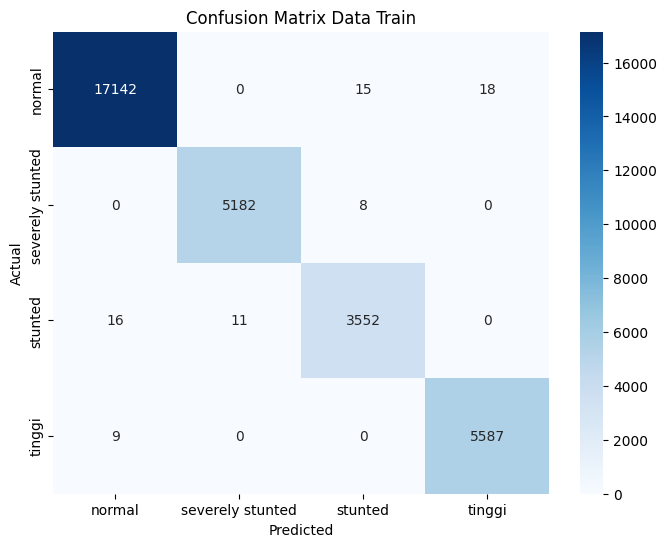

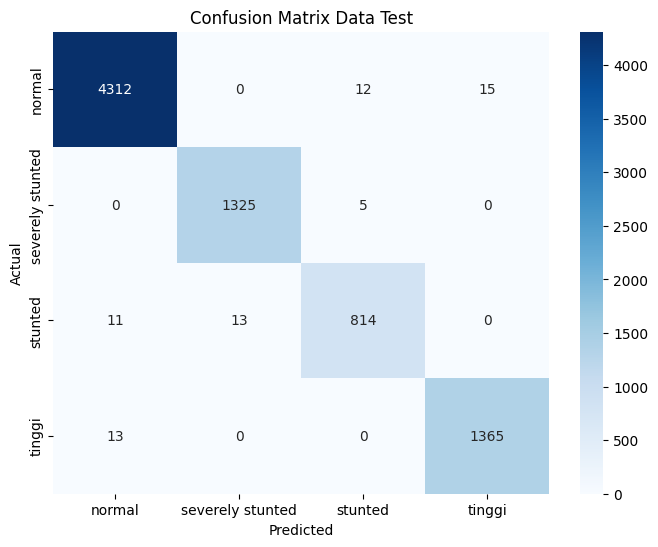

In [163]:
# Data Train
cm = confusion_matrix(y_train, y_pred_train)

labels = encoders['Status Gizi'].classes_

#Membuat visualisasi heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Data Train')
plt.show()


# Data Test 
cm = confusion_matrix(y_test, y_pred)

labels = encoders['Status Gizi'].classes_

#Membuat visualisasi heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Data Test')
plt.show()

# Tuning Hyperparameter (K)

In [164]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21],  # Mencoba berbagai nilai k
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1 # Menampilkan log proses pencarian
)


grid_search.fit(X_train_smote, y_train_smote)

# 4. Tampilkan hasil terbaik
print("\nHyperparameter terbaik yang ditemukan:")
print(grid_search.best_params_)

print(f"\nSkor F1-macro terbaik dari cross-validation: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Hyperparameter terbaik yang ditemukan:
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}

Skor F1-macro terbaik dari cross-validation: 0.9972


# Saved Model and Scaler

In [165]:
# Simpan Objek ke File 
joblib.dump(knn_model, 'knn_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(encoders, 'encoders.joblib')

# Inverse Scaling Target
status_gizi_encoder = encoders['Status Gizi']
inverse_status_gizi_mapping = {i: cls for i, cls in enumerate(status_gizi_encoder.classes_)}
joblib.dump(inverse_status_gizi_mapping, 'inverse_status_gizi_mapping.joblib')

['inverse_status_gizi_mapping.joblib']

# Saved Data Train for API Development

In [166]:
df = pd.read_csv("data_balita_include_bb.csv", sep=",")
df = df.drop(columns=["Status Gizi"])
df = df.sample(n=50, random_state=42) 
df.to_csv("test_data.csv", index=False)